!curl -fsSL https://ollama.com/install.sh | sh# Research Paper -> Chemistry Knowledge Graph Pipeline

Reads one or more research paper **PDFs** and extracts **only chemistry-related** entities, relations, and (subject, relation, object) triples using a local Ollama LLM — filtering out authors, institutions, funding, figure/table references, and any other non-chemistry content. Builds and visualizes a combined chemistry knowledge graph across all papers.

Pipeline: `PDF -> clean text -> chunk -> LLM extraction (chemistry-only prompt) -> chemistry filter -> merge -> graph`

In [2]:
import ollama

models = ollama.list()

for m in models.models:
    print(m.model, m.size)

qwen2.5:7b 4683087332
deepseek-r1:7b 4683075440


In [3]:
import json
import pickle
import re
import time
from pathlib import Path

import ollama
import networkx as nx
import matplotlib.pyplot as plt
from pypdf import PdfReader


In [4]:
import sys

print(sys.version)

3.9.16 (main, Mar 16 2023, 13:07:12) 
[GCC 11.2.0]


## 1. Configuration

Put your paper PDFs in `PAPERS_DIR` (defaults to a `papers/` folder next to this notebook).

In [40]:
from pathlib import Path
from typing import Optional
import pickle

# =========================================================
# Project paths
# =========================================================

PROJECT_DIR = Path.home() / "Mini_Project"

PAPERS_DIR = PROJECT_DIR / "papers"
OUTPUT_DIR = PROJECT_DIR / "Outputs"

MODEL_NAME = "qwen2.5:7b"

CHUNK_MAX_CHARS = 3000
CHUNK_OVERLAP_CHARS = 200


# =========================================================
# Create directories
# =========================================================

PAPERS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# Output files
# =========================================================

CHECKPOINT_FILE = OUTPUT_DIR / "chemistry_extraction.pkl"
GRAPH_PKL_FILE = OUTPUT_DIR / "knowledge_graph.pkl"
GRAPH_PNG_FILE = OUTPUT_DIR / "knowledge_graph.png"
RESULTS_JSON_FILE = OUTPUT_DIR / "knowledge_graph.json"


# =========================================================
# Find PDFs
# =========================================================

pdf_paths = sorted(PAPERS_DIR.glob("*.pdf"))

print("Project directory :", PROJECT_DIR.resolve())
print("Papers directory  :", PAPERS_DIR.resolve())
print("Output directory  :", OUTPUT_DIR.resolve())

if not pdf_paths:
    print(f"\nNo PDFs found in '{PAPERS_DIR}/'.")
    print("Add research paper PDFs there and re-run this cell.")

else:
    print(f"\nFound {len(pdf_paths)} PDF(s):")

    for p in pdf_paths:
        print(" -", p.name)


# =========================================================
# Load checkpoint
# =========================================================

def load_checkpoint() -> Optional[dict]:
    """
    Load a previously saved extraction checkpoint.
    Returns None if no checkpoint exists.
    """

    if CHECKPOINT_FILE.exists():

        with open(CHECKPOINT_FILE, "rb") as f:
            return pickle.load(f)

    return None

Project directory : /jupyter/sods.user30/Mini_Project
Papers directory  : /jupyter/sods.user30/Mini_Project/papers
Output directory  : /jupyter/sods.user30/Mini_Project/Outputs

Found 4 PDF(s):
 - Adv Funct Materials - 2026 - Zhang - High‐Throughput Design of Active MXene Catalysts for Li O2 Battery Using Machine.pdf
 - JDSIS62028409_R1.pdf
 - am6c00201.pdf
 - s41524-022-00713-x.pdf


## 1b. Resume from a checkpoint (run this any time)

Cells in this notebook build on state produced by earlier cells (extracted triples -> graph -> visualization), so they aren't independent by default. This cell removes that dependency across sessions: every time the extraction step (section 9) finishes, it saves a checkpoint to disk. If you restart the kernel, or just want to re-run the graph/visualization/export cells without waiting for the LLM again, run this cell and then jump straight to section 10 onward.

In [9]:
_checkpoint = load_checkpoint()
if _checkpoint is not None:
    extraction = _checkpoint
    domain_dictionary = extraction["domain_dictionary"]
    relation_keywords = extraction["relation_keywords"]
    triples = extraction["triples"]
    print(
        f"Loaded checkpoint from {CHECKPOINT_FILE} "
        f"({len(domain_dictionary)} entities, {len(triples)} triples).\n"
        "You can skip straight to section 10 (Build graph) instead of re-running the extraction cell."
    )
else:
    print(
        f"No checkpoint found at {CHECKPOINT_FILE} yet.\n"
        "Run section 9 (Run the pipeline) at least once first - it saves a checkpoint automatically."
    )


No checkpoint found at C:\Users\anagh\OneDrive\Desktop\DUK\mini_pro\saved_extraction/chemistry_extraction.pkl yet.
Run section 9 (Run the pipeline) at least once first - it saves a checkpoint automatically.


## 2. PDF text extraction and cleanup

In [10]:
def extract_text_from_pdf(pdf_path: Path) -> str:
    """Extract raw text from every page of a PDF and normalize whitespace."""
    reader = PdfReader(str(pdf_path))
    pages = [page.extract_text() or "" for page in reader.pages]
    raw = "\n".join(pages)

    # Rejoin words that were hyphenated across a line break: "theo-\nretical" -> "theoretical"
    raw = re.sub(r"-\s*\n\s*", "", raw)
    # Collapse 3+ newlines to a paragraph break, and single newlines (line wraps) to spaces
    raw = re.sub(r"\n{2,}", "\n\n", raw)
    raw = re.sub(r"(?<!\n)\n(?!\n)", " ", raw)
    raw = re.sub(r"[ \t]{2,}", " ", raw)
    return raw.strip()


def strip_references(text: str) -> str:
    """Cut the text off at a References/Bibliography heading (searched only in the
    back half of the document, to avoid false positives from in-body mentions)."""
    half = len(text) // 2
    for pattern in (r"\breferences\b", r"\bbibliography\b", r"\bworks cited\b"):
        matches = list(re.finditer(pattern, text[half:], re.IGNORECASE))
        if matches:
            return text[: half + matches[0].start()].strip()
    return text


def load_paper_text(pdf_path: Path) -> str:
    text = extract_text_from_pdf(pdf_path)
    text = strip_references(text)
    return text


## 3. Chunking (local LLMs have a limited context window)

In [11]:
def chunk_text(text: str, max_chars: int = CHUNK_MAX_CHARS, overlap_chars: int = CHUNK_OVERLAP_CHARS) -> list[str]:
    """Split text into LLM-sized chunks on paragraph boundaries, with a little
    overlap between chunks so relations spanning a boundary aren't lost."""
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    chunks, current = [], ""

    for para in paragraphs:
        if len(current) + len(para) + 1 <= max_chars:
            current = f"{current}\n{para}" if current else para
            continue

        if current:
            chunks.append(current)
            current = current[-overlap_chars:] + "\n" + para
        else:
            for i in range(0, len(para), max_chars):
                chunks.append(para[i:i + max_chars])
            current = ""

    if current:
        chunks.append(current)
    return chunks


## 4. Prompt template (chemistry-only extraction)

The prompt itself instructs the model to ignore non-chemistry content. This is the first line of defense. A second, code-based filter in step 7 acts as a backstop in case the model still leaks something non-chemical through.

In [12]:
def build_prompt(source_text: str) -> str:
    """Build the chemistry-only extraction prompt sent to the LLM for one chunk of paper text."""
    return f"""You are a chemistry knowledge graph extraction system.

Extract ONLY chemistry-related information from the excerpt below. This is an
excerpt from a research paper, but the paper may also discuss non-chemistry
topics (authors, affiliations, funding, figures/tables, unrelated background) —
IGNORE all of that. Only extract facts about chemical substances, materials,
reactions, chemical/physical properties, and characterization or synthesis
techniques.

Extract:
1. domain_dictionary  -- maps each chemistry-relevant entity to a short category
   label. Categories MUST be chemistry categories, e.g.: chemical, compound,
   material, catalyst, solvent, salt, electrolyte, reaction, product,
   intermediate, property, technique, instrument, process, structure, phase,
   device, electrode.
2. relation_keywords  -- maps each relation verb/phrase used to a normalized
   relation name (e.g. "consists of", "catalyzes", "is dissolved in",
   "increases", "is measured by").
3. triples            -- a list of (subject, relation, object) chemistry facts
   stated in the text. Both subject and object must be chemistry entities from
   domain_dictionary.

STRICT RULES:
- Do NOT extract author names, institutions, universities, funding agencies,
  grant numbers, journal names, citation numbers, figure/table labels, or
  page/section references.
- Do NOT extract generic statements that have no chemical substance, material,
  reaction, property, or technique in them.
- Use entity and relation names EXACTLY as they appear (or a short normalized
  form) in the text.
- Every subject/object used in "triples" must also appear as a key in
  "domain_dictionary".
- Do not invent facts that are not supported by the text.
- If the excerpt contains no chemistry-relevant facts, return empty
  dictionaries/lists.
- Return ONLY valid JSON. No explanation, no markdown, no code fences, no
  extra text.

JSON schema:

{{
  "domain_dictionary": {{
    "entity": "chemistry_category"
  }},
  "relation_keywords": {{
    "verb": "relation"
  }},
  "triples": [
    {{
      "subject": "",
      "relation": "",
      "object": ""
    }}
  ]
}}

Text excerpt:

{source_text}
"""


## 5. Call the local LLM (with retries)

In [13]:
def call_ollama(prompt: str, model: str = MODEL_NAME, retries: int = 3, delay: float = 2.0) -> str:
    """Call the local Ollama model and return the raw text response, retrying on transient errors."""
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            response = ollama.chat(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0},  # deterministic extraction
            )
            return response["message"]["content"]
        except Exception as err:  # noqa: BLE001 - surface any ollama/connection error
            last_err = err
            print(f"  [attempt {attempt}/{retries}] ollama call failed: {err}")
            if attempt < retries:
                time.sleep(delay)
    raise RuntimeError(f"ollama call failed after {retries} attempts") from last_err


## 6. Robust JSON parsing

In [14]:
def extract_json(raw: str) -> dict:
    """Pull the first valid top-level JSON object out of an LLM response.

    Handles the common failure modes of local LLMs: markdown code fences,
    leading/trailing commentary, and trailing commas.
    """
    cleaned = raw.strip()
    cleaned = re.sub(r"^```(?:json)?", "", cleaned).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    start = cleaned.find("{")
    if start == -1:
        raise ValueError("No JSON object found in model output:\n" + raw)

    depth = 0
    for i in range(start, len(cleaned)):
        if cleaned[i] == "{":
            depth += 1
        elif cleaned[i] == "}":
            depth -= 1
            if depth == 0:
                candidate = cleaned[start:i + 1]
                try:
                    return json.loads(candidate)
                except json.JSONDecodeError:
                    repaired = re.sub(r",\s*([\]}])", r"\1", candidate)
                    return json.loads(repaired)

    raise ValueError("Unbalanced JSON braces in model output:\n" + raw)


## 7. Chemistry-only filter (code-based backstop)

Even with a strict prompt, local LLMs occasionally leak a stray author name or figure reference into the output. This filter checks every entity's category against a chemistry keyword list and drops anything that doesn't match — plus any triple that references a dropped entity.

In [15]:
CHEMISTRY_CATEGORY_KEYWORDS = (
    "chemical", "compound", "molecule", "material", "polymer", "catalyst",
    "solvent", "salt", "acid", "base", "reagent", "electrolyte", "metal",
    "nanoparticle", "nanomaterial", "oxide", "element", "ion", "ionic",
    "ligand", "reaction", "product", "byproduct", "intermediate", "precursor",
    "property", "technique", "method", "instrument", "equipment", "process",
    "mechanism", "structure", "phase", "crystal", "particle", "gas", "liquid",
    "solid", "mixture", "sample", "substrate", "film", "battery", "electrode",
    "anode", "cathode", "device", "synthesis", "characterization", "spectroscopy",
    "microscopy", "diffraction",
)

# Word-boundary match so short keywords (e.g. "ion") don't match inside
# unrelated words (e.g. "institution").
_CHEM_PATTERN = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in CHEMISTRY_CATEGORY_KEYWORDS) + r")\b",
    re.IGNORECASE,
)


def normalize_category(category) -> str:
    """Coerce a category value to a plain string, no matter what shape the LLM
    returned it in. Local LLMs occasionally return a category as a list
    (e.g. ["material", "compound"]), a dict, a number, or null instead of a
    plain string -- this makes every downstream step (filtering, coloring)
    robust to that."""
    if isinstance(category, str):
        return category
    if isinstance(category, (list, tuple, set)):
        return " ".join(normalize_category(c) for c in category)
    if isinstance(category, dict):
        return " ".join(normalize_category(v) for v in category.values())
    if category is None:
        return ""
    return str(category)


def normalize_domain_dictionary(domain_dictionary: dict) -> dict:
    """Normalize every category value in a domain_dictionary to a string, and
    drop entries whose entity name isn't a usable non-empty string."""
    normalized = {}
    for entity, category in domain_dictionary.items():
        if not isinstance(entity, str) or not entity.strip():
            continue
        normalized[entity.strip()] = normalize_category(category).strip() or "unknown"
    return normalized


def is_chemistry_category(category) -> bool:
    """True if a category label looks chemistry-related."""
    text = normalize_category(category).replace("_", " ").replace("-", " ")
    return bool(_CHEM_PATTERN.search(text))


def filter_to_chemistry(domain_dictionary: dict, triples: list[dict]) -> tuple[dict, list[dict]]:
    """Keep only chemistry-categorized entities, and only triples where both
    the subject and object survived the filter."""
    domain_dictionary = normalize_domain_dictionary(domain_dictionary)

    chem_entities = {entity for entity, category in domain_dictionary.items()
                      if is_chemistry_category(category)}

    filtered_dictionary = {entity: category for entity, category in domain_dictionary.items()
                            if entity in chem_entities}

    filtered_triples = [
        t for t in triples
        if t.get("subject") in chem_entities and t.get("object") in chem_entities
    ]

    return filtered_dictionary, filtered_triples


## 8. Merge extraction results across chunks and papers

In [16]:
def merge_extraction(accumulated: dict, new_data: dict, source: str) -> None:
    """Merge one chunk's extracted dict into the running accumulator, tagging
    each triple with the paper it came from."""
    accumulated.setdefault("domain_dictionary", {}).update(new_data.get("domain_dictionary", {}))
    accumulated.setdefault("relation_keywords", {}).update(new_data.get("relation_keywords", {}))

    triples_acc = accumulated.setdefault("triples", [])
    for t in new_data.get("triples", []):
        subject = str(t.get("subject", "")).strip()
        relation = str(t.get("relation", "")).strip()
        obj = str(t.get("object", "")).strip()
        if not subject or not relation or not obj:
            continue
        triples_acc.append({"subject": subject, "relation": relation, "object": obj, "source": source})


def dedupe_triples(triples: list[dict]) -> list[dict]:
    """Remove exact duplicate (subject, relation, object) triples, case-insensitively.
    Keeps the first source seen; merges any additional sources into 'also_in'."""
    seen = {}
    out = []
    for t in triples:
        key = (t["subject"].lower(), t["relation"].lower(), t["object"].lower())
        if key in seen:
            existing = seen[key]
            if t["source"] != existing["source"] and t["source"] not in existing.setdefault("also_in", []):
                existing["also_in"].append(t["source"])
            continue
        seen[key] = t
        out.append(t)
    return out


In [17]:
import ollama

print("Ollama Python package:", ollama.__file__)

try:
    models = ollama.list()
    print(models)
except Exception as e:
    print("ERROR:", e)

Ollama Python package: /jupyter/sods.user30/.local/lib/python3.9/site-packages/ollama/__init__.py
models=[Model(model='qwen2.5:7b', modified_at=datetime.datetime(2026, 8, 4, 17, 21, 16, 13171, tzinfo=TzInfo(19800)), digest='845dbda0ea48ed749caafd9e6037047aa19acfcfd82e704d7ca97d631a0b697e', size=4683087332, details=ModelDetails(parent_model='', format='gguf', family='qwen2', families=['qwen2'], parameter_size='7.6B', quantization_level='Q4_K_M')), Model(model='deepseek-r1:7b', modified_at=datetime.datetime(2026, 8, 4, 14, 5, 48, 427292, tzinfo=TzInfo(19800)), digest='755ced02ce7befdb13b7ca74e1e4d08cddba4986afdb63a480f2c93d3140383f', size=4683075440, details=ModelDetails(parent_model='', format='gguf', family='qwen2', families=['qwen2'], parameter_size='7.6B', quantization_level='Q4_K_M'))]


## 9. Run the pipeline over every paper

In [19]:
extraction = {"domain_dictionary": {}, "relation_keywords": {}, "triples": []}

for pdf_path in pdf_paths:
    print(f"\nProcessing {pdf_path.name}...")
    paper_text = load_paper_text(pdf_path)
    chunks = chunk_text(paper_text)
    print(f"  {len(paper_text)} chars -> {len(chunks)} chunk(s)")

    for i, chunk in enumerate(chunks):
        print(f"  chunk {i + 1}/{len(chunks)}: calling {MODEL_NAME}...")
        prompt = build_prompt(chunk)
        raw_result = call_ollama(prompt)
        try:
            chunk_data = extract_json(raw_result)
        except ValueError as err:
            print(f"    Skipping chunk {i + 1}: {err}")
            continue

        # Apply the chemistry-only filter before merging, so non-chemistry
        # content never makes it into the combined graph.
        chem_dictionary, chem_triples = filter_to_chemistry(
            chunk_data.get("domain_dictionary", {}), chunk_data.get("triples", [])
        )
        chunk_data["domain_dictionary"] = chem_dictionary
        chunk_data["triples"] = chem_triples

        merge_extraction(extraction, chunk_data, source=pdf_path.name)

extraction["triples"] = dedupe_triples(extraction["triples"])

domain_dictionary = extraction["domain_dictionary"]
relation_keywords = extraction["relation_keywords"]
triples = extraction["triples"]

print(f"\nTotal chemistry entities: {len(domain_dictionary)} | relation types: {len(relation_keywords)} | triples: {len(triples)}")

# Save a checkpoint immediately, so section 10 onward can be re-run later
# (even after a kernel restart) without re-running this LLM-calling cell.
with open(CHECKPOINT_FILE, "wb") as f:
    pickle.dump(extraction, f)
print(f"Checkpoint saved to {CHECKPOINT_FILE}")



Processing Adv Funct Materials - 2026 - Zhang - High‐Throughput Design of Active MXene Catalysts for Li O2 Battery Using Machine.pdf...
  48212 chars -> 23 chunk(s)
  chunk 1/23: calling qwen2.5:7b...
  chunk 2/23: calling qwen2.5:7b...
  chunk 3/23: calling qwen2.5:7b...
  chunk 4/23: calling qwen2.5:7b...
  chunk 5/23: calling qwen2.5:7b...
  chunk 6/23: calling qwen2.5:7b...
  chunk 7/23: calling qwen2.5:7b...
  chunk 8/23: calling qwen2.5:7b...
  chunk 9/23: calling qwen2.5:7b...
  chunk 10/23: calling qwen2.5:7b...
  chunk 11/23: calling qwen2.5:7b...
  chunk 12/23: calling qwen2.5:7b...
  chunk 13/23: calling qwen2.5:7b...
  chunk 14/23: calling qwen2.5:7b...
  chunk 15/23: calling qwen2.5:7b...
  chunk 16/23: calling qwen2.5:7b...
  chunk 17/23: calling qwen2.5:7b...
  chunk 18/23: calling qwen2.5:7b...
  chunk 19/23: calling qwen2.5:7b...
  chunk 20/23: calling qwen2.5:7b...
  chunk 21/23: calling qwen2.5:7b...
  chunk 22/23: calling qwen2.5:7b...
  chunk 23/23: calling qwen2.

## 10. Build the directed chemistry knowledge graph

In [35]:
# Guard: if extraction results aren't in memory (e.g. fresh kernel, or you
# jumped straight to this cell), load them from the checkpoint on disk instead
# of requiring section 9 to have just been run in this session.
if "triples" not in globals():
    _checkpoint = load_checkpoint()
    if _checkpoint is None:
        raise RuntimeError(
            "No extraction results in memory and no checkpoint found on disk. "
            "Run section 9 (Run the pipeline) first, or section 1b if a checkpoint already exists."
        )
    extraction = _checkpoint
    domain_dictionary = extraction["domain_dictionary"]
    relation_keywords = extraction["relation_keywords"]
    triples = extraction["triples"]
    print("Loaded extraction results from checkpoint.")

G = nx.DiGraph()

for triple in triples:
    subject, relation, obj = triple["subject"], triple["relation"], triple["object"]
    G.add_node(subject)
    G.add_node(obj)
    G.add_edge(subject, obj, label=relation, source=triple["source"])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Save the graph object itself, so later cells (visualization, export) can be
# re-run independently later without rebuilding it from the triples.
with open(GRAPH_PKL_FILE, "wb") as f:
    pickle.dump(G, f)
print(f"Graph object saved to {GRAPH_PKL_FILE}")


Graph built: 210 nodes, 156 edges
Graph object saved to Mini_Project\Outputs/knowledge_graph.pkl


## 11. Visualize the graph (nodes colored by chemistry category)

Nodes : 210
Edges : 156


/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 38081 (\N{CJK UNIFIED IDEOGRAPH-94C1}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 30967 (\N{CJK UNIFIED IDEOGRAPH-78F7}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 37240 (\N{CJK UNIFIED IDEOGRAPH-9178}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 30416 (\N{CJK UNIFIED IDEOGRAPH-76D0}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 38146 (\N{CJK UNIFIED IDEOGRAPH-9502}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 38221 (\N{CJK UNIFIED IDEOGRAPH-954D}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_3463749/19103795.py:122: UserWarning: Glyph 38192 (\N{CJK UNIFIED IDEOGRAPH-9530}) missing from font(s)

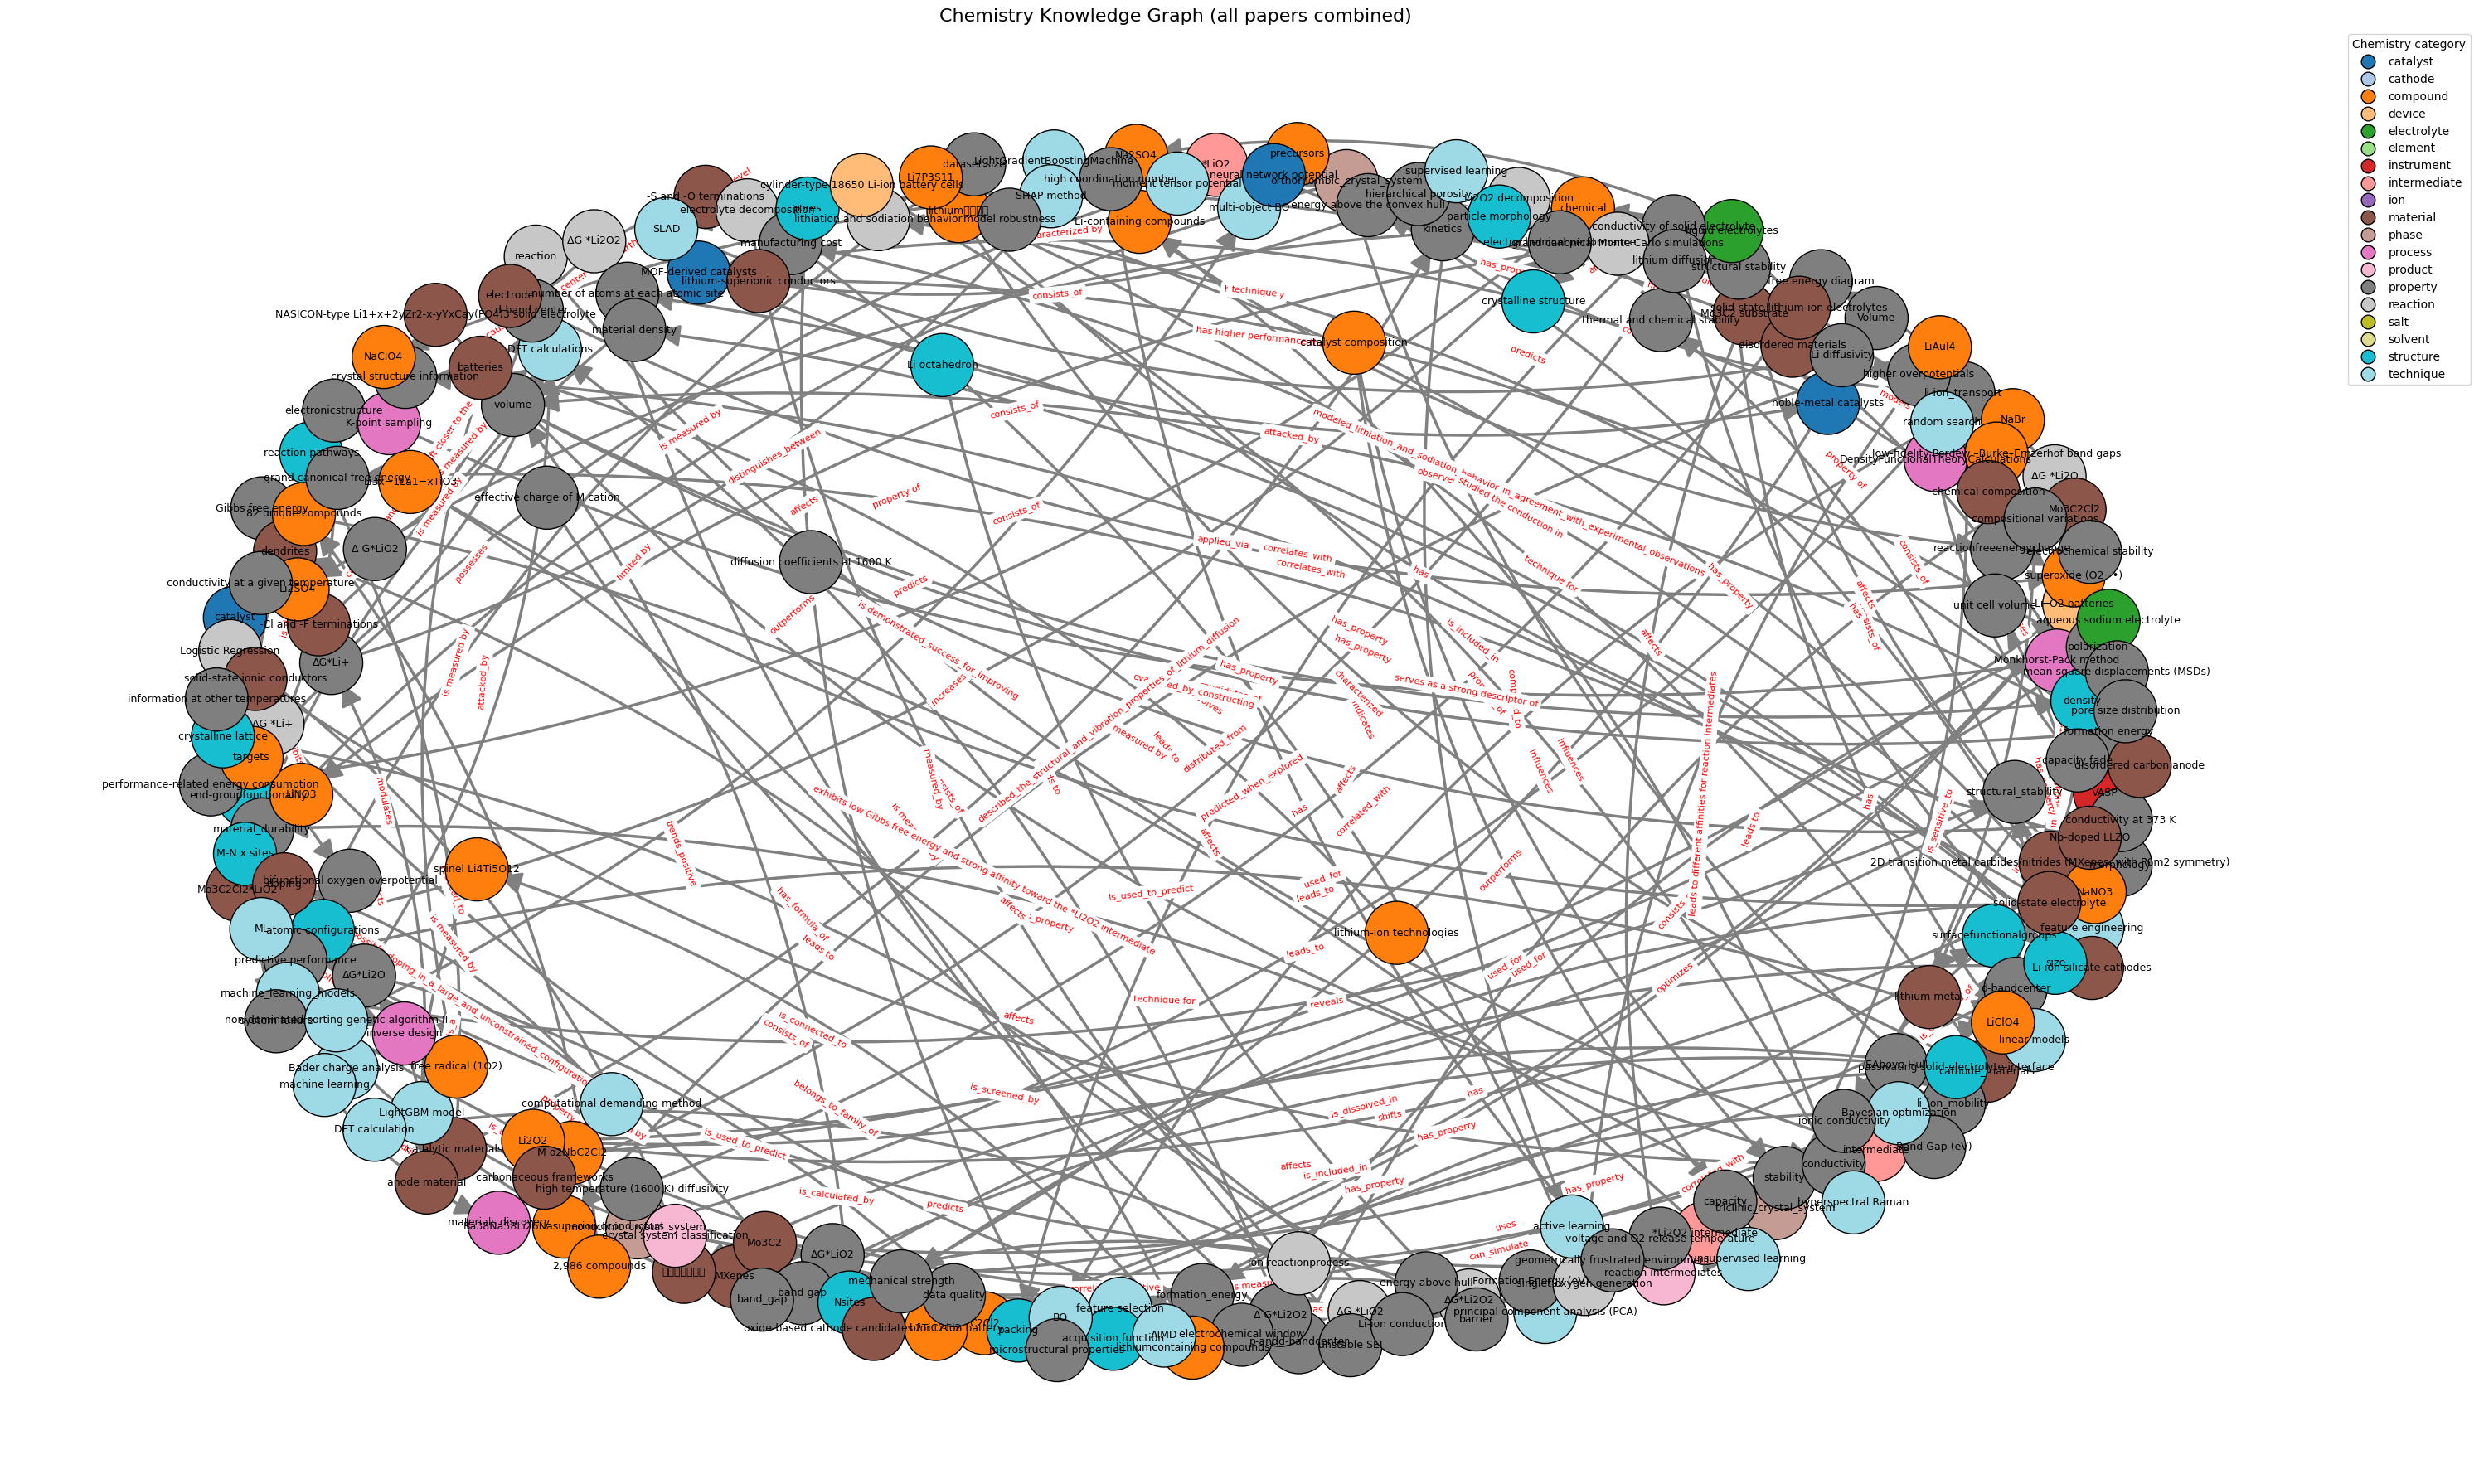

In [41]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt


def draw_knowledge_graph(
    graph: nx.DiGraph,
    domain_map: dict,
    figsize=(30, 18)
) -> None:

    # Get categories
    categories = sorted(set(domain_map.values())) or ["unknown"]

    # Create color map
    cmap = plt.colormaps.get_cmap("tab20").resampled(
        max(len(categories), 1)
    )

    category_color = {
        cat: cmap(i)
        for i, cat in enumerate(categories)
    }

    # Assign colors to nodes
    node_colors = [
        category_color.get(
            domain_map.get(node, "unknown"),
            (0.53, 0.81, 0.92, 1.0)
        )
        for node in graph.nodes()
    ]

    # Create figure
    plt.figure(figsize=figsize)

    # Layout
    pos = nx.spring_layout(
        graph,
        seed=42,
        k=1.5
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=3000,
        node_color=node_colors,
        edgecolors="black"
    )

    # Draw node labels
    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=9
    )

    # Draw directed edges
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=list(graph.edges()),
        arrows=True,
        arrowstyle="-|>",
        arrowsize=40,
        width=2.5,
        edge_color="gray",
        min_source_margin=20,
        min_target_margin=20,
        connectionstyle="arc3,rad=0.15"
    )

    # Edge labels
    edge_labels = nx.get_edge_attributes(
        graph,
        "label"
    )

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_color="red",
        font_size=8
    )

    # Legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=category_color[cat],
            markersize=12,
            markeredgecolor="black",
            label=cat
        )
        for cat in categories
    ]

    if handles:
        plt.legend(
            handles=handles,
            loc="upper left",
            bbox_to_anchor=(1, 1),
            title="Chemistry category"
        )

    # Title
    plt.title(
        "Chemistry Knowledge Graph (all papers combined)",
        fontsize=16
    )

    plt.axis("off")
    plt.tight_layout()

    # Save graph
    plt.savefig(
        GRAPH_PNG_FILE,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ---------------------------------------------------------
# Load graph if it is not already in memory
# ---------------------------------------------------------

if "G" not in globals():

    if GRAPH_PKL_FILE.exists():

        with open(GRAPH_PKL_FILE, "rb") as f:
            G = pickle.load(f)

        print(
            f"Loaded graph from {GRAPH_PKL_FILE} "
            f"({G.number_of_nodes()} nodes, "
            f"{G.number_of_edges()} edges)."
        )

    else:

        raise RuntimeError(
            "No graph in memory and no saved graph found on disk. "
            "Run section 10 (Build the graph) first."
        )


# ---------------------------------------------------------
# Load domain dictionary if necessary
# ---------------------------------------------------------

if "domain_dictionary" not in globals():

    _checkpoint = load_checkpoint()

    if _checkpoint is None:

        raise RuntimeError(
            "No domain_dictionary in memory and no checkpoint found "
            "on disk. Run section 9 (Run the pipeline) first."
        )

    domain_dictionary = _checkpoint["domain_dictionary"]


# ---------------------------------------------------------
# Draw graph
# ---------------------------------------------------------

if G.number_of_nodes() == 0:

    print(
        "No chemistry entities were extracted - "
        "nothing to visualize."
    )

else:

    print(f"Nodes : {G.number_of_nodes()}")
    print(f"Edges : {G.number_of_edges()}")

    draw_knowledge_graph(
        G,
        domain_dictionary
    )

## 12. Export results

Saves the merged chemistry triples/dictionaries (each triple tagged with its source paper) so the graph can be reused or re-filtered without re-running the LLM.

In [42]:
# Guard: make sure we have extraction results and a graph to export, loading
# from disk if this cell is being run on its own (fresh kernel, out of order).
if "extraction" not in globals():
    _checkpoint = load_checkpoint()
    if _checkpoint is None:
        raise RuntimeError(
            "No extraction results in memory and no checkpoint found on disk. "
            "Run section 9 (Run the pipeline) first."
        )
    extraction = _checkpoint

if "G" not in globals():
    if GRAPH_PKL_FILE.exists():
        with open(GRAPH_PKL_FILE, "rb") as f:
            G = pickle.load(f)
    else:
        raise RuntimeError("No graph in memory and no saved graph found. Run section 10 first.")

# 1. Human-readable triples/dictionaries as JSON
with open(RESULTS_JSON_FILE, "w", encoding="utf-8") as f:
    json.dump(extraction, f, indent=2, ensure_ascii=False)

# 2. The networkx graph object itself, so it can be reloaded later with
#    `pickle.load()` instead of rebuilt from triples - e.g. for further
#    analysis (centrality, subgraph queries, merging with another graph).
with open(GRAPH_PKL_FILE, "wb") as f:
    pickle.dump(G, f)

# 3. The extraction checkpoint (kept in sync in case this cell is run after
#    further edits to `extraction` that weren't checkpointed yet).
with open(CHECKPOINT_FILE, "wb") as f:
    pickle.dump(extraction, f)

# Note: GRAPH_PNG_FILE was already written by the visualization cell (section 11).

print("Saved:")
print(f" - {RESULTS_JSON_FILE}")
print(f" - {GRAPH_PKL_FILE}")
print(f" - {GRAPH_PNG_FILE}")
print(f" - {CHECKPOINT_FILE}")


Saved:
 - /jupyter/sods.user30/Mini_Project/Outputs/knowledge_graph.json
 - /jupyter/sods.user30/Mini_Project/Outputs/knowledge_graph.pkl
 - /jupyter/sods.user30/Mini_Project/Outputs/knowledge_graph.png
 - /jupyter/sods.user30/Mini_Project/Outputs/chemistry_extraction.pkl
